In [1]:
install.packages("readr")

library(readr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [8]:
# LAB 3 - Load UCI Heart Disease Dataset

url <- "https://raw.githubusercontent.com/StatQuest/logistic_regression_demo/master/processed.cleveland.data"

heart_data <- read.csv(url, header = FALSE)

# Add column names
colnames(heart_data) <- c(
  "age",
  "sex",
  "cp",
  "trestbps",
  "chol",
  "fbs",
  "restecg",
  "thalach",
  "exang",
  "oldpeak",
  "slope",
  "ca",
  "thal",
  "num"
)

# Convert ? to NA
heart_data[heart_data == "?"] <- NA

# Convert columns to numeric
heart_data[] <- lapply(heart_data, function(x) as.numeric(as.character(x)))

head(heart_data)
str(heart_data)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
2,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
3,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
4,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
5,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
6,56,1,2,120,236,0,0,178,0,0.8,1,0,3,0


'data.frame':	303 obs. of  14 variables:
 $ age     : num  63 67 67 37 41 56 62 57 63 53 ...
 $ sex     : num  1 1 1 1 0 1 0 0 1 1 ...
 $ cp      : num  1 4 4 3 2 2 4 4 4 4 ...
 $ trestbps: num  145 160 120 130 130 120 140 120 130 140 ...
 $ chol    : num  233 286 229 250 204 236 268 354 254 203 ...
 $ fbs     : num  1 0 0 0 0 0 0 0 0 1 ...
 $ restecg : num  2 2 2 0 2 0 2 0 2 2 ...
 $ thalach : num  150 108 129 187 172 178 160 163 147 155 ...
 $ exang   : num  0 1 1 0 0 0 0 1 0 1 ...
 $ oldpeak : num  2.3 1.5 2.6 3.5 1.4 0.8 3.6 0.6 1.4 3.1 ...
 $ slope   : num  3 2 2 3 1 1 3 1 2 3 ...
 $ ca      : num  0 3 2 0 0 0 2 0 1 0 ...
 $ thal    : num  6 3 7 3 3 3 3 3 7 7 ...
 $ num     : num  0 2 1 0 0 0 3 0 2 1 ...


In [9]:
# Check BP and cholesterol

summary(heart_data$trestbps)
summary(heart_data$chol)

cat("Number of rows:", nrow(heart_data), "\n")
cat("Number of columns:", ncol(heart_data), "\n")

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   94.0   120.0   130.0   131.7   140.0   200.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  126.0   211.0   241.0   246.7   275.0   564.0 

Number of rows: 303 
Number of columns: 14 


In [10]:
set.seed(123)

# Introduce negative BP values
heart_data$trestbps[sample(1:nrow(heart_data), 3)] <- -20

# Introduce missing values
heart_data$trestbps[sample(1:nrow(heart_data), 3)] <- NA

# Introduce extreme BP values
heart_data$trestbps[sample(1:nrow(heart_data), 3)] <- 320

summary(heart_data$trestbps)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  -20.0   120.0   130.0   132.8   140.0   320.0       3 

In [11]:
clean_bp <- function(bp) {

  if (is.na(bp)) {
    return(NA)
  } else if (bp < 0) {
    return(NA)
  } else if (bp > 250) {
    return(250)
  } else {
    return(bp)
  }
}

In [12]:
heart_data$trestbps_clean <- sapply(
  heart_data$trestbps,
  clean_bp
)

head(heart_data[, c("trestbps", "trestbps_clean")])

,trestbps,trestbps_clean
,<dbl>,<dbl>
1,145,145
2,160,160
3,120,120
4,130,130
5,130,130
6,120,120


In [13]:
safe_mean_bp <- function(bp) {

  result <- tryCatch(
    {
      if (all(is.na(bp))) {
        stop("All BP values are missing.")
      }

      mean(bp, na.rm = TRUE)
    },
    warning = function(w) {
      message("Warning: ", w$message)
      NA
    },
    error = function(e) {
      message("Error: ", e$message)
      NA
    }
  )

  return(result)
}

mean_bp <- safe_mean_bp(heart_data$trestbps_clean)

cat("Mean BP:", mean_bp, "\n")

Mean BP: 133.1376 


In [14]:
safe_ratio <- function(chol, bp) {

  tryCatch(
    {
      if (is.na(chol) || is.na(bp)) {
        stop("Cholesterol or BP is NA.")
      }

      if (bp <= 0) {
        stop("Invalid denominator: BP must be greater than zero.")
      }

      chol / bp
    },
    error = function(e) {
      message("Error calculating ratio: ", e$message)
      NA
    }
  )
}

heart_data$chol_bp_ratio <- mapply(
  safe_ratio,
  heart_data$chol,
  heart_data$trestbps_clean
)

head(heart_data[, c("chol", "trestbps_clean", "chol_bp_ratio")])

Error calculating ratio: Cholesterol or BP is NA.

Error calculating ratio: Cholesterol or BP is NA.

Error calculating ratio: Cholesterol or BP is NA.

Error calculating ratio: Cholesterol or BP is NA.

Error calculating ratio: Cholesterol or BP is NA.



,chol,trestbps_clean,chol_bp_ratio
,<dbl>,<dbl>,<dbl>
1,233,145,1.606897
2,286,160,1.787500
3,229,120,1.908333
4,250,130,1.923077
5,204,130,1.569231
6,236,120,1.966667


In [15]:
bp <- heart_data$trestbps

system.time({

  invalid_loop <- logical(length(bp))

  for (i in seq_along(bp)) {
    if (is.na(bp[i]) || bp[i] < 0 || bp[i] > 250) {
      invalid_loop[i] <- TRUE
    } else {
      invalid_loop[i] <- FALSE
    }
  }
})

   user  system elapsed 
  0.006   0.000   0.005 

In [16]:
system.time({

  invalid_vectorized <- is.na(bp) | bp < 0 | bp > 250
})

   user  system elapsed 
  0.001   0.000   0.001 

In [17]:
cat("Invalid values using loop:",
    sum(invalid_loop), "\n")

cat("Invalid values using vectorized method:",
    sum(invalid_vectorized), "\n")

cat("Both methods give same result:",
    identical(invalid_loop, invalid_vectorized), "\n")

Invalid values using loop: 8 
Invalid values using vectorized method: 8 
Both methods give same result: TRUE 


In [18]:
loop_time <- system.time({

  for (i in seq_along(bp)) {
    if (is.na(bp[i]) || bp[i] < 0 || bp[i] > 250) {
      invalid_loop[i] <- TRUE
    }
  }
})

vector_time <- system.time({

  invalid_vectorized <- is.na(bp) | bp < 0 | bp > 250
})

cat("Loop time:", loop_time["elapsed"], "seconds\n")
cat("Vectorized time:", vector_time["elapsed"], "seconds\n")

Loop time: 0.005 seconds
Vectorized time: 0 seconds


In [19]:
clean_bp_values <- heart_data$trestbps_clean

cat("Missing BP values:",
    sum(is.na(clean_bp_values)), "\n")

cat("Minimum BP:",
    min(clean_bp_values, na.rm = TRUE), "\n")

cat("Maximum BP:",
    max(clean_bp_values, na.rm = TRUE), "\n")

cat("Mean BP:",
    mean(clean_bp_values, na.rm = TRUE), "\n")

cat("Median BP:",
    median(clean_bp_values, na.rm = TRUE), "\n")

cat("Negative values remaining:",
    sum(clean_bp_values < 0, na.rm = TRUE), "\n")

cat("Values > 250 remaining:",
    sum(clean_bp_values > 250, na.rm = TRUE), "\n")

Missing BP values: 5 
Minimum BP: 94 
Maximum BP: 250 
Mean BP: 133.1376 
Median BP: 130 
Negative values remaining: 0 
Values > 250 remaining: 0 


In [20]:
write.csv(
  heart_data,
  "cleaned_heart_data.csv",
  row.names = FALSE
)

cat("File saved successfully.")

File saved successfully.

In [21]:
adult_url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

adult <- read.csv(
  adult_url,
  header = FALSE,
  na.strings = "?",
  strip.white = TRUE
)

colnames(adult) <- c(
  "age",
  "workclass",
  "fnlwgt",
  "education",
  "education_num",
  "marital_status",
  "occupation",
  "relationship",
  "race",
  "sex",
  "capital_gain",
  "capital_loss",
  "hours_per_week",
  "native_country",
  "income"
)

head(adult)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [22]:
set.seed(123)

# NA
adult$age[sample(1:nrow(adult), 5)] <- NA

# Blank strings
adult$workclass[sample(1:nrow(adult), 5)] <- ""

# NaN
adult$education_num[sample(1:nrow(adult), 5)] <- NaN

# Impossible age
adult$age[sample(1:nrow(adult), 3)] <- 999

head(adult)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<dbl>,<chr>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [23]:
cat("Number of NA values:",
    sum(is.na(adult)), "\n")

cat("Number of NaN values:",
    sum(is.nan(as.matrix(adult[, sapply(adult, is.numeric)]))), "\n")

# Demonstrate NULL
x <- NULL

cat("Is x NULL?",
    is.null(x), "\n")

# Blank strings
cat("Blank workclass values:",
    sum(adult$workclass == "", na.rm = TRUE), "\n")

# Impossible age
cat("Age = 999:",
    sum(adult$age == 999, na.rm = TRUE), "\n")

Number of NA values: 4272 
Number of NaN values: 5 
Is x NULL? TRUE 
Blank workclass values: 5 
Age = 999: 3 


In [24]:
missing_summary <- data.frame(
  Variable = names(adult),
  Missing_Count = sapply(adult, function(x) sum(is.na(x))),
  Missing_Percentage = sapply(adult, function(x)
    mean(is.na(x)) * 100
  )
)

missing_summary

,Variable,Missing_Count,Missing_Percentage
,<chr>,<int>,<dbl>
age,age,5,0.01535579
workclass,workclass,1836,5.63864746
fnlwgt,fnlwgt,0,0.00000000
education,education,0,0.00000000
education_num,education_num,5,0.01535579
marital_status,marital_status,0,0.00000000
occupation,occupation,1843,5.66014557
relationship,relationship,0,0.00000000
race,race,0,0.00000000


In [25]:
median_impute <- function(x) {

  if (!is.numeric(x)) {
    stop("Input must be numeric.")
  }

  median_value <- median(x, na.rm = TRUE)

  x[is.na(x)] <- median_value

  return(x)
}

In [26]:
adult$age[adult$age == 999] <- NA

cat("Age = 999 remaining:",
    sum(adult$age == 999, na.rm = TRUE), "\n")

Age = 999 remaining: 0 


In [27]:
adult$workclass[
  is.na(adult$workclass) | adult$workclass == ""
] <- "Unknown"

adult$occupation[
  is.na(adult$occupation) | adult$occupation == ""
] <- "Unknown"

adult$native_country[
  is.na(adult$native_country) | adult$native_country == ""
] <- "Unknown"

In [28]:
numeric_columns <- c(
  "age",
  "fnlwgt",
  "education_num",
  "capital_gain",
  "capital_loss",
  "hours_per_week"
)

for (col in numeric_columns) {
  adult[[col]] <- median_impute(adult[[col]])
}

head(adult)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<dbl>,<chr>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [29]:
complete_rows <- complete.cases(adult)

cat("Complete observations:",
    sum(complete_rows), "\n")

cat("Incomplete observations:",
    sum(!complete_rows), "\n")

Complete observations: 32561 
Incomplete observations: 0 


In [30]:
after_summary <- data.frame(
  Variable = names(adult),
  Missing_Count = sapply(adult, function(x) sum(is.na(x))),
  Missing_Percentage = sapply(adult, function(x)
    mean(is.na(x)) * 100
  )
)

after_summary

,Variable,Missing_Count,Missing_Percentage
,<chr>,<int>,<dbl>
age,age,0,0
workclass,workclass,0,0
fnlwgt,fnlwgt,0,0
education,education,0,0
education_num,education_num,0,0
marital_status,marital_status,0,0
occupation,occupation,0,0
relationship,relationship,0,0
race,race,0,0


In [31]:
install.packages(c("naniar", "skimr"))

library(naniar)
library(skimr)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’



Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete




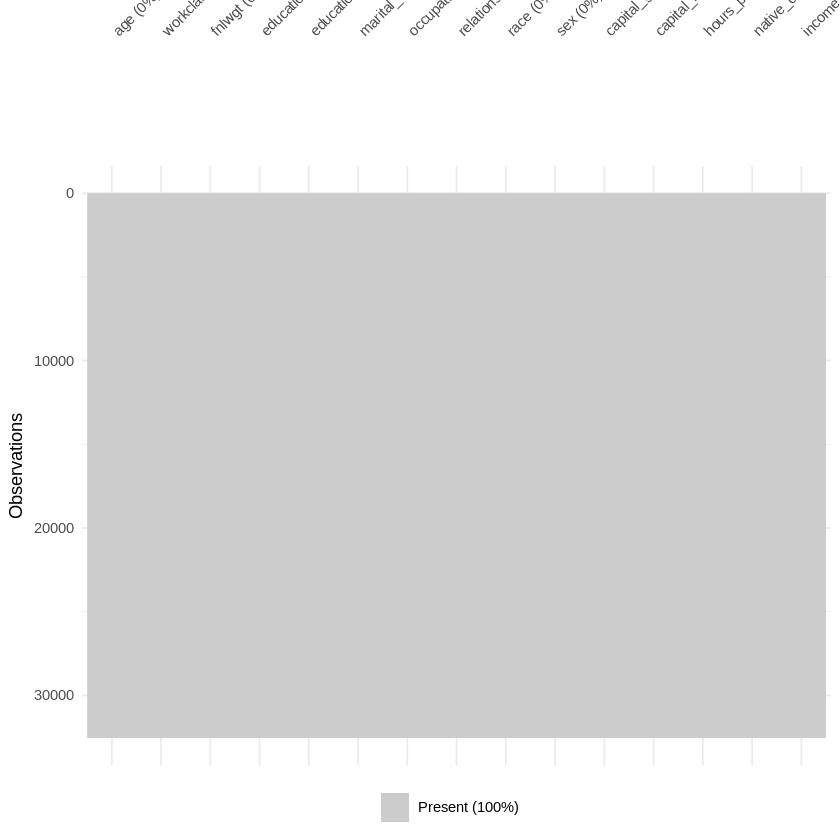

In [32]:
vis_miss(adult)

In [33]:
miss_var_summary(adult)

variable,n_miss,pct_miss
<chr>,<int>,<num>
age,0,0
workclass,0,0
fnlwgt,0,0
education,0,0
education_num,0,0
marital_status,0,0
occupation,0,0
relationship,0,0
race,0,0


In [34]:
skim(adult)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,workclass,0,1,7,16,0,9,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,education,0,1,3,12,0,16,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,marital_status,0,1,7,21,0,7,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,occupation,0,1,5,17,0,15,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,relationship,0,1,4,14,0,6,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,race,0,1,5,18,0,5,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,sex,0,1,4,6,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,native_country,0,1,4,26,0,42,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,income,0,1,4,5,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA


In [35]:
cat("Age 999 remaining:",
    sum(adult$age == 999, na.rm = TRUE), "\n")

cat("Blank workclass values:",
    sum(adult$workclass == "", na.rm = TRUE), "\n")

cat("Missing age values:",
    sum(is.na(adult$age)), "\n")

cat("Missing education_num values:",
    sum(is.na(adult$education_num)), "\n")

cat("Missing hours_per_week values:",
    sum(is.na(adult$hours_per_week)), "\n")

Age 999 remaining: 0 
Blank workclass values: 0 
Missing age values: 0 
Missing education_num values: 0 
Missing hours_per_week values: 0 


In [36]:
write.csv(
  adult,
  "cleaned_adult_data.csv",
  row.names = FALSE
)

cat("cleaned_adult_data.csv created successfully.")

cleaned_adult_data.csv created successfully.